In [2]:
# libs
import matplotlib
import heapq
import math

In [3]:
# Orbit characteristics

class OrbitFeatures():
    def __init__(self, altitude_km, max_temperature_C, pressure_tor, density_kg_m3):
        # Constants 
        self.G = 6.6743e-11 # Nm^2kg^-2
        self.g = 9.80665 # ms^-2
        self.earth_mass = 5.9722e24 # kg
        self.u = self.G * self.earth_mass
        self.earth_radius_km = 6378.0

        self.altitude_km = altitude_km
        self.max_temperature_C = max_temperature_C
        self.pressure_tor = pressure_tor
        self.density_kg_m3 = density_kg_m3
        self.orbit_radius_m = (self.earth_radius_km + self.altitude_km) * 1000

        self.accel_ms2 = self.u/(self.orbit_radius_m*self.orbit_radius_m)
        self.velocity_ms = math.sqrt(self.u/self.orbit_radius_m)

orbits = list()
orbits.append(OrbitFeatures(150, 361.24, 3.4070e-6, 2.076e-9))
orbits.append(OrbitFeatures(200, 581.41, 6.3597e-7, 2.541e-10))
orbits.append(OrbitFeatures(250, 668.18, 1.8577e-7, 6.073e-11))
orbits.append(OrbitFeatures(300, 702.86, 6.5783e-8, 1.916e-11))
orbits.append(OrbitFeatures(350, 716.91, 2.5876e-8, 7.014e-12))
orbits.append(OrbitFeatures(400, 722.68, 1.0889e-8, 2.803e-12))
orbits.append(OrbitFeatures(450, 725.07, 4.8355e-9, 1.184e-12))
orbits.append(OrbitFeatures(500, 726.09, 2.2679e-9, 5.215e-13))
orbits.append(OrbitFeatures(550, 726.52, 1.1354e-9, 2.384e-13))
orbits.append(OrbitFeatures(600, 726.70, 6.1602e-10,1.137e-13))
orbits.append(OrbitFeatures(650, 726.78, 3.6651e-10,5.712e-14))
orbits.append(OrbitFeatures(700, 726.82, 2.3933e-10,3.070e-14))
orbits.append(OrbitFeatures(750, 726.84, 1.6951e-10,1.788e-14))
orbits.append(OrbitFeatures(800, 726.84, 1.2778e-10,1.136e-14))
orbits.append(OrbitFeatures(850, 726.85, 1.0062e-10,7.824e-15))
orbits.append(OrbitFeatures(900, 726.85, 8.1556e-11,5.759e-15))
orbits.append(OrbitFeatures(950, 726.85, 6.7368e-11,4.453e-15))
orbits.append(OrbitFeatures(1000,726.85, 5.6358e-11,3.561e-15))

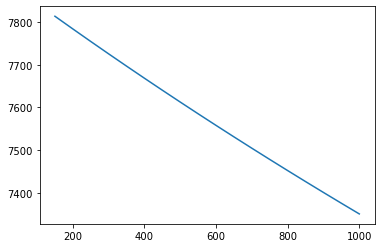

In [4]:
# plot pressure and density function or orbit
import matplotlib.pyplot as plt
import numpy as np

# define data values
x = list()
y_temp = list()
y_pressure = list()
y_density = list()
y_velocity = list()

for orbit in orbits:
    x.append(orbit.altitude_km)
    y_temp.append(orbit.max_temperature_C)
    y_pressure.append(orbit.pressure_tor)
    y_density.append(orbit.density_kg_m3)
    y_velocity.append(orbit.velocity_ms)

plt.plot(x, y_velocity)
plt.show()

In [5]:

class Satellite():
    def __init__(self,x_m,y_m,z_m,mass_kg,CD):
        self.x_m = x_m
        self.y_m = y_m
        self.z_m = z_m
        self.mass_kg = mass_kg
        self.CD = CD
        self.surface_area_m2 = self._find_max_SA()
    def _find_max_SA(self):
        # assume rectangular SA, find max SA
        x_y = heapq.nlargest(2, [self.x_m, self.y_m, self.z_m])
        return x_y[0] * x_y[1]

cubesat_1U = Satellite(0.1,0.1,0.1,1.5,2.2)
cubesat_3U = Satellite(0.3,0.1,0.1,4.5,2.2)
cubesat_12U = Satellite(0.3,0.2,0.2,20,2.2)
Small_Sat = Satellite(0.55,0.55,0.3,123,2.2)

In [6]:
class SystemAnalysis():
    def __init__(self, orbit:OrbitFeatures, sat:Satellite):
        self.orbit = orbit
        self.sat = sat

    def newton_orbit_force(self):
        return ((self.orbit.u * self.sat.mass_kg)/self.orbit.orbit_radius_m^2)

    def drag_force(self):
        return (1/2) * self.orbit.density_kg_m3*(self.sat.CD * self.sat.surface_area_m2)*self.orbit.velocity_ms*self.orbit.velocity_ms

    def delta_accel_per_orbit(self):
        return 2*math.pi * (self.sat.CD*(self.sat.surface_area_m2/self.sat.mass_kg))*self.orbit.density_kg_m3*self.orbit.accel_ms2*self.orbit.accel_ms2

    def delta_period_per_orbit(self):
        return 6*math.pi^2 * (self.sat.CD*(self.sat.surface_area_m2/self.sat.mass_kg))*self.orbit.density_kg_m3*self.orbit.accel_ms2*self.orbit.accel_ms2/self.orbit.velocity_ms
   
    def delta_v_per_orbit(self):
        return math.pi * (self.sat.CD*(self.sat.surface_area_m2/self.sat.mass_kg))*self.orbit.density_kg_m3*self.orbit.accel_ms2*self.orbit.velocity_ms
    
    def solar_rad_force(self):
        return self.sat.surface_area_m2 * 4.513e-6


150 ,  0.008366527865005148 ,  275.78858610776393 ,  87212.00847780053
200 ,  0.0010165073008982608 ,  96.12999252424532 ,  30398.972783157427
250 ,  0.00024131947451038447 ,  46.838161840958904 ,  14811.527283301539
300 ,  7.575098871509075e-05 ,  26.242053120047036 ,  8298.465833847666
350 ,  2.7696862692688828e-05 ,  15.86788142262935 ,  5017.864693698163
400 ,  1.1150194804648981e-05 ,  10.068038901146078 ,  3183.793449880044
450 ,  4.83264251394587e-06 ,  6.628205923411271 ,  2096.022751859919
500 ,  2.265473367634109e-06 ,  4.538194843000612 ,  1435.1032169512182
550 ,  1.176058850715104e-06 ,  3.269777377346971 ,  1033.994395410828
600 ,  6.994405352804988e-07 ,  2.5216166085929492 ,  797.4051868863036
650 ,  4.845961219320478e-07 ,  2.0989090714681624 ,  663.7333267428526
700 ,  3.848868770653461e-07 ,  1.870553824321814 ,  591.52105707954
750 ,  3.367708657171111e-07 ,  1.7497295004374276 ,  553.3130510570855
800 ,  3.1241502979093005e-07 ,  1.685270492966337 ,  532.9293231248

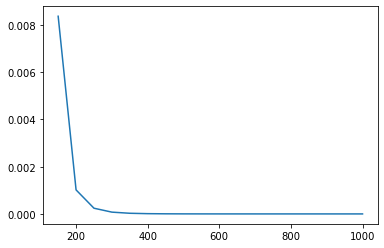

In [21]:

# Results 
altitudes = []
force = []
current = []
predicted_current = []
for orbit in orbits:
    system = SystemAnalysis(orbit, cubesat_12U)
    altitudes.append(system.orbit.altitude_km)
    force.append(system.drag_force()+system.solar_rad_force())
    current.append(math.sqrt((2*force[-1])/0.22e-6))
    predicted_current.append(math.sqrt((2*(force[-1] /(0.001 * 0.1 * 0.1)))/0.22e-6))
    # duty cycle, efficiency, lifetime operation percentage
    print(system.orbit.altitude_km, ", ", force[-1], ", ", current[-1], ", ", predicted_current[-1])
plt.plot(altitudes, force)
plt.show()
    
